In [39]:
import pandas as pd
import geopandas as gpd
import numpy as np
from fsspec import filesystem 

fs = filesystem('https')

In [40]:
df = gpd.read_parquet(
    "https://github.com/oturns/example_datasets/raw/refs/heads/main/acs/ca_tracts_2021.pq", filesystem=fs
)
df = df.to_crs(32611)
df = df.replace({np.inf:np.nan})
df['pop_density'] = df.n_total_pop / df.area

la = df[df.geoid.str.startswith("06037")]
oc = df[df.geoid.str.startswith("06059")]
rside = df[df.geoid.str.startswith("06065")]

Create a san diego dataframe (`sd`) (hint: the SD county fips code is '06073')

In [42]:
sd = ## your answer here

## Chi Square

In [63]:
import pandas as pd
import scipy

types = ["truck", "sportscar", "hatchback", "minivan"]
draw = scipy.stats.chi2.rvs(4, 0, size=5, random_state=2)
#print(draw)

car_df = dict(zip(types, draw))
car_df = pd.Series(car_df)
car_df = car_df / car_df.sum()
car_df = car_df*400

You are a transportation planner collecting data on car accidents. After tabulating the data for one month, you count the number of fatal accidents by vehicle type, which results in data like these:

<Axes: >

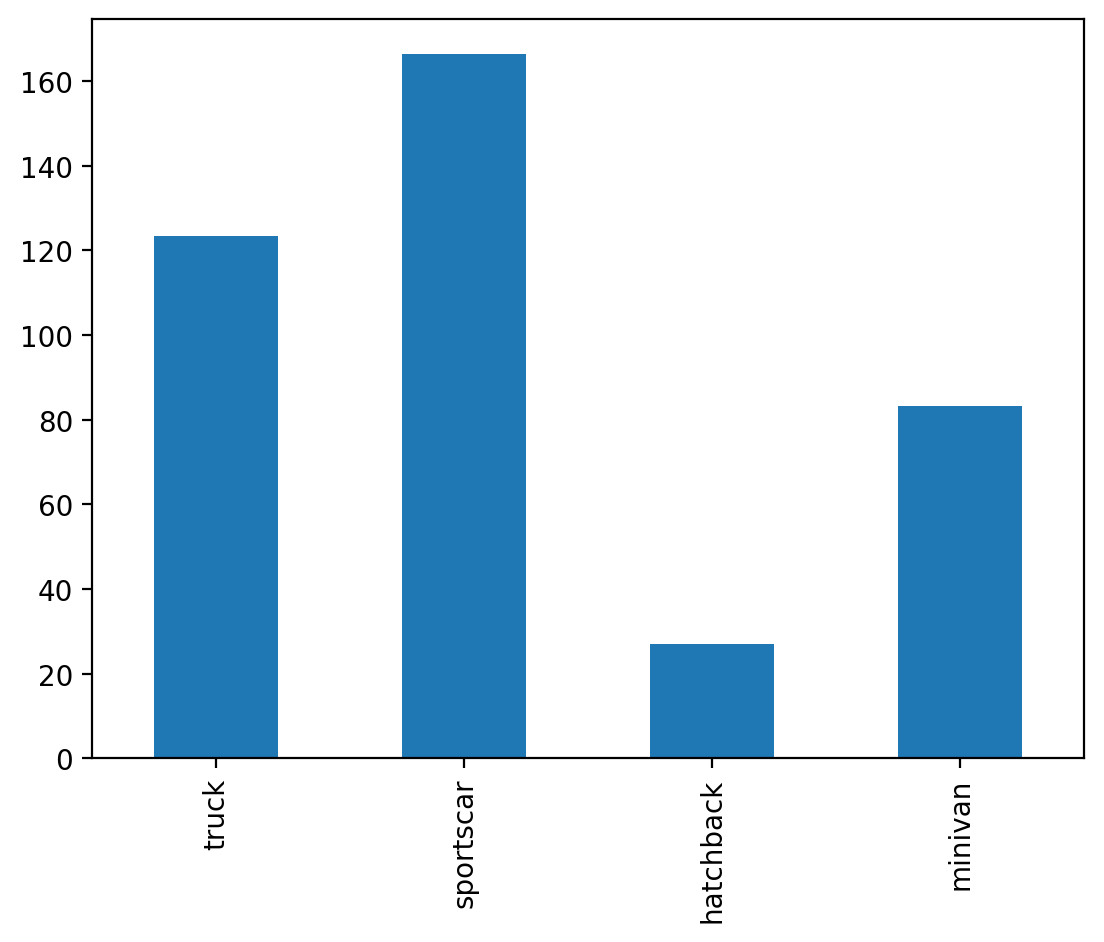

In [64]:
car_df.plot(kind='bar')

you're curious whether some vehicle types are more accident prone than others and decide to use a chi-square goodness of fit test to examine whether these vechicles get into accidents at the same rates

In words, write down the null and alternative hypotheses:

- H0:

- HA: 


In [18]:
from scipy.stats import chisquare

In [58]:
chisquare(car_df)

Power_divergenceResult(statistic=np.float64(105.70179446434558), pvalue=np.float64(9.229541132133133e-23))

According to conventional standards, do we reject or fail to reject the null hypothesis?

## T-test

In [3]:
from scipy.stats import ttest_ind

We are curious whether an inland county is more "rural" than a coastal county, assuming average population density in a neighborhood is a good measure of urban/rural. Above, we calculated population density into a new variable called "pop_density". Use a two-sample t-test to compare population density in Riverside and Orange counties

In words, write down the null and alternative hypotheses:

- H0:

- HA: 

We start by comparing two coastal counties, Orange and San Diego

In [16]:
sd_oc = ttest_ind(sd.pop_density, oc.pop_density, equal_var=False)

In [17]:
sd_oc

TtestResult(statistic=np.float64(-2.0747571456377107), pvalue=np.float64(0.03819849690768878), df=np.float64(1347.3755942794253))

What is the p-value for the test above? Under conventional levels ($\alpha=0.05$), do we reject or accept the null hypothesis?

Now do the test for Orange and Riverside Counties using the `ttest_ind` function (assume *different* variances)

In [1]:
## your answer here

Do we accept or reject the null hypothesis?

## ANOVA

In [28]:
from scipy.stats import f_oneway

You are interested in the labor market conditions in southern california. Specifically, you want to know if the neighborhood-level unemployment rate is the same in LA, Orange, and SD counties.

In [49]:
oc.p_unemployment_rate.mean()

np.float64(6.080652961102818)

In [50]:
sd.p_unemployment_rate.mean()

np.float64(7.485555783961273)

In [51]:
la.p_unemployment_rate.mean()

np.float64(9.574423961846268)

Write the null and alternative hypotheses that you will test

use the `f_oneway` function to test this hypothesis (include `nan_policy='omit'` to make sure we ignore any NaN values)

In [2]:
# your answer here

Assuming conventional standards, do we reject or fail to reject the null hypothesis?

In words, describe what the p-value represents